# Generic PWR Dry Cask Shielding Model

This notebook models a generic pressurized water reactor (PWR) dry cask storage container in OpenMC.
The geometry is loosely based on publicly available specifications for multi-purpose canisters (MPC)
such as the Holtec HI-STORM 100 system.

## Geometry overview
- **Fuel region**: 4×4 array of PWR fuel assemblies (17×17 pin lattice each), simplified to
  homogenized assemblies inside a basket structure for tractable run times.
- **Canister**: 5/8" stainless steel 304 inner canister, helium backfill.
- **Overpack**: Thick-walled carbon steel outer overpack with concrete fill between steel shells.

## Analysis goal
Compute neutron and photon dose rates through a radial cross-section of the cask using a
mesh flux tally and ANSI/ANS-6.1.1 flux-to-dose conversion factors.

## Key dimensions (approximate, generic)
| Component | Dimension |
|---|---|
| Fuel active length | 365.8 cm |
| MPC inner diameter | 170.2 cm |
| MPC wall thickness | 1.27 cm (1/2") |
| Overpack inner diameter | 175.3 cm |
| Concrete shield thickness | 60 cm |
| Outer steel shell thickness | 2.54 cm |
| Total cask outer diameter | ~307 cm |

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import openmc
import openmc.stats

# Cross sections — set both config dict and env var for compatibility
CROSS_SECTIONS = '/home/eric/openmc/nuclear_data/endf-b8.0-hdf5/endfb-viii.0-hdf5/cross_sections.xml'
openmc.config['cross_sections'] = CROSS_SECTIONS
os.environ['OPENMC_CROSS_SECTIONS'] = str(CROSS_SECTIONS)

print(f'OpenMC version: {openmc.__version__}')
print(f'Cross sections: {openmc.config["cross_sections"]}')

OpenMC version: 0.15.2
Cross sections: /home/eric/openmc/nuclear_data/endf-b8.0-hdf5/endfb-viii.0-hdf5/cross_sections.xml


## Cell 2 — Materials

Spent fuel composition is based on a typical PWR assembly at ~45 GWd/tHM burnup with
~10 years of cooling. We use a simplified actinide + major fission product composition
representative of that discharge state. For a production model you would use OpenMC's
depletion module or import an Origen output.

Photon production from the spent fuel is dominated by fission product gamma emitters
(primarily Cs-137/Ba-137m, Eu-154, Co-60). We include the most significant ones.

In [2]:
# ---------------------------------------------------------------------------
# Spent UO2 fuel — 45 GWd/tHM burnup, ~10 year cooling
# Composition from NUREG/CR-6781 Table 3 (simplified, dominant nuclides)
# ---------------------------------------------------------------------------
spent_fuel = openmc.Material(name='spent_uo2')
spent_fuel.set_density('g/cm3', 10.4)

# Actinides (weight fractions relative to initial HM, normalized here to atom fractions)
spent_fuel.add_nuclide('U234',  1.80e-4, 'wo')
spent_fuel.add_nuclide('U235',  8.10e-3, 'wo')   # ~0.81 wt% after burnup
spent_fuel.add_nuclide('U236',  5.20e-3, 'wo')
spent_fuel.add_nuclide('U238',  9.20e-1, 'wo')   # dominant uranium isotope
spent_fuel.add_nuclide('Pu238', 2.10e-4, 'wo')
spent_fuel.add_nuclide('Pu239', 5.90e-3, 'wo')
spent_fuel.add_nuclide('Pu240', 2.60e-3, 'wo')
spent_fuel.add_nuclide('Pu241', 1.00e-3, 'wo')
spent_fuel.add_nuclide('Pu242', 5.50e-4, 'wo')
spent_fuel.add_nuclide('Am241', 4.20e-4, 'wo')

# Major fission products (neutron absorbers + gamma sources)
spent_fuel.add_nuclide('Cs137', 2.80e-3, 'wo')   # key gamma source (662 keV via Ba-137m)
spent_fuel.add_nuclide('Eu154', 1.80e-4, 'wo')   # gamma source
spent_fuel.add_nuclide('Sm149', 4.00e-5, 'wo')   # strong absorber
spent_fuel.add_nuclide('Nd143', 8.00e-4, 'wo')   # absorber
spent_fuel.add_nuclide('Nd145', 6.20e-4, 'wo')
spent_fuel.add_nuclide('Rh103', 3.20e-4, 'wo')
spent_fuel.add_nuclide('Ru101', 4.80e-4, 'wo')
spent_fuel.add_nuclide('Mo95',  5.80e-4, 'wo')
spent_fuel.add_nuclide('Tc99',  7.20e-4, 'wo')
spent_fuel.add_nuclide('Zr93',  5.50e-4, 'wo')
spent_fuel.add_element('O',     1.34e-1, 'wo')   # oxygen in UO2
spent_fuel.add_nuclide('Sr90',  1.50e-3, 'wo')   # beta/bremsstrahlung source
spent_fuel.add_nuclide('Kr85',  1.20e-4, 'wo')   # fission gas retained

# ---------------------------------------------------------------------------
# Zircaloy-4 cladding
# ---------------------------------------------------------------------------
zircaloy = openmc.Material(name='zircaloy4')
zircaloy.set_density('g/cm3', 6.56)
zircaloy.add_element('Zr', 0.9825, 'wo')
zircaloy.add_element('Sn', 0.0145, 'wo')
zircaloy.add_element('Fe', 0.0021, 'wo')
zircaloy.add_element('Cr', 0.0010, 'wo')

# ---------------------------------------------------------------------------
# Helium backfill (canister atmosphere)
# ---------------------------------------------------------------------------
helium = openmc.Material(name='helium')
helium.set_density('g/cm3', 1.664e-4)  # ~1 atm, 300 K
helium.add_element('He', 1.0, 'ao')

# ---------------------------------------------------------------------------
# Stainless steel 304 (canister shell and basket structure)
# ---------------------------------------------------------------------------
ss304 = openmc.Material(name='ss304')
ss304.set_density('g/cm3', 8.03)
ss304.add_element('Fe', 0.6892, 'wo')
ss304.add_element('Cr', 0.19,   'wo')
ss304.add_element('Ni', 0.10,   'wo')
ss304.add_element('Mn', 0.02,   'wo')
ss304.add_element('Si', 0.01,   'wo')
ss304.add_element('C',  0.0008, 'wo')

# ---------------------------------------------------------------------------
# Carbon steel (overpack outer shells)
# ---------------------------------------------------------------------------
carbon_steel = openmc.Material(name='carbon_steel')
carbon_steel.set_density('g/cm3', 7.85)
carbon_steel.add_element('Fe', 0.9865, 'wo')
carbon_steel.add_element('C',  0.0025, 'wo')
carbon_steel.add_element('Mn', 0.0075, 'wo')
carbon_steel.add_element('Si', 0.0035, 'wo')

# ---------------------------------------------------------------------------
# Ordinary concrete (overpack shield fill)
# NIST composition, density 2.3 g/cm3
# ---------------------------------------------------------------------------
concrete = openmc.Material(name='concrete')
concrete.set_density('g/cm3', 2.3)
concrete.add_element('H',  0.0101, 'wo')
concrete.add_element('O',  0.5290, 'wo')
concrete.add_element('Na', 0.0153, 'wo')
concrete.add_element('Mg', 0.0021, 'wo')
concrete.add_element('Al', 0.0469, 'wo')
concrete.add_element('Si', 0.3155, 'wo')
concrete.add_element('K',  0.0192, 'wo')
concrete.add_element('Ca', 0.0826, 'wo')
concrete.add_element('Fe', 0.0124, 'wo')

# ---------------------------------------------------------------------------
# Homogenized fuel assembly material
# A 17×17 PWR assembly has 264 fuel pins, 24 guide tubes, 1 instrument tube.
# We volume-average fuel, clad, and water over the assembly pitch cell.
# Pin pitch: 1.26 cm, fuel pellet r: 0.4096 cm, clad outer r: 0.4750 cm
# Assembly pitch: 21.5 cm (17 * 1.26 + 0.08 cm wrapper)
# ---------------------------------------------------------------------------
pin_pitch   = 1.26      # cm
r_fuel      = 0.4096    # cm  fuel pellet radius
r_clad_i    = 0.4179    # cm  clad inner radius
r_clad_o    = 0.4750    # cm  clad outer radius
assy_pitch  = 21.50     # cm  assembly outer dimension
n_fuel_pins = 264
n_pins_tot  = 289       # 17x17

v_cell      = pin_pitch**2            # cm² per pin cell (unit cell area)
v_fuel      = np.pi * r_fuel**2
v_clad      = np.pi * (r_clad_o**2 - r_clad_i**2)
v_gap       = np.pi * (r_clad_i**2 - r_fuel**2)
v_mod       = v_cell - np.pi * r_clad_o**2   # moderator (water) per pin cell

# Volume fractions over assembly cross-section
# (264 fuel pins + 24 guide/instrument tubes filled with water)
assy_area   = assy_pitch**2
total_fuel  = n_fuel_pins * v_fuel
total_clad  = n_fuel_pins * v_clad
total_gap   = n_fuel_pins * v_gap    # He gap
total_water = assy_area - total_fuel - total_clad - total_gap

vf_fuel  = total_fuel  / assy_area
vf_clad  = total_clad  / assy_area
vf_gap   = total_gap   / assy_area
vf_water = total_water / assy_area

print('Homogenized assembly volume fractions:')
print(f'  Fuel:  {vf_fuel:.4f}')
print(f'  Clad:  {vf_clad:.4f}')
print(f'  He gap:{vf_gap:.4f}')
print(f'  Water: {vf_water:.4f}')

# In a dry cask the coolant water has been removed — replaced by helium fill.
# So we homogenize: fuel + clad + helium (no water).
# Renormalize vf without water:
vf_tot_dry = vf_fuel + vf_clad + vf_gap
vf_fuel_n  = vf_fuel / vf_tot_dry
vf_clad_n  = vf_clad / vf_tot_dry
vf_gap_n   = vf_gap  / vf_tot_dry

rho_fuel_hom = vf_fuel_n * 10.4 + vf_clad_n * 6.56 + vf_gap_n * 1.664e-4

hom_fuel = openmc.Material(name='hom_fuel_assembly')
hom_fuel.set_density('g/cm3', rho_fuel_hom)
# Mix by volume fraction * density = mass fraction weight
# OpenMC mix_materials handles this cleanly:
hom_fuel = openmc.Material.mix_materials(
    [spent_fuel, zircaloy, helium],
    [vf_fuel_n,  vf_clad_n, vf_gap_n],
    'vo'
)
hom_fuel.name = 'hom_fuel_assembly'

print(f'\nHomogenized fuel density: {hom_fuel.density:.3f} g/cm3')

Homogenized assembly volume fractions:
  Fuel:  0.3010
  Clad:  0.0915
  He gap:0.0123
  Water: 0.5952

Homogenized fuel density: 9.216 g/cm3


## Cell 3 — Geometry: Cask cross-section

We model a **2D radial slice** (infinite in z) through the mid-plane of the cask.
This is standard practice for shielding dose-rate calculations at the cask side surface.

### Layout (radial, inside-out)
```
  ┌─────────────────────────────────────────────┐
  │  Outer air / void (scoring region)           │
  │  ┌─────────────────────────────────────────┐ │
  │  │  Outer carbon steel shell (2.54 cm)     │ │
  │  │  ┌─────────────────────────────────────┐│ │
  │  │  │  Concrete shield (60 cm)            ││ │
  │  │  │  ┌─────────────────────────────────┐││ │
  │  │  │  │  Inner carbon steel shell (5 cm)│││ │
  │  │  │  │  ┌───────────────────────────┐  │││ │
  │  │  │  │  │  SS304 canister (1.27 cm) │  │││ │
  │  │  │  │  │  ┌───────────────────────┴┐ │││ │
  │  │  │  │  │  │  Helium gap            │ │││ │
  │  │  │  │  │  │  ┌────────────────────┴┐│││ │
  │  │  │  │  │  │  │  4x4 fuel assemblies│││││ │
  │  │  │  │  │  │  │  + SS basket        │││││ │
  │  │  │  │  │  │  └────────────────────┘│││ │
  └─────────────────────────────────────────────┘
```

Radii (cm from centerline):
- Basket region (fuel+SS): 0 – 60.0 cm
- He gap: 60.0 – 83.5 cm  
- MPC SS wall: 83.5 – 84.77 cm  
- Inner steel overpack: 84.77 – 89.77 cm  
- Concrete: 89.77 – 149.77 cm  
- Outer steel shell: 149.77 – 152.31 cm  
- Scoring air: 152.31 – 200 cm

In [3]:
# ---------------------------------------------------------------------------
# Radial dimensions (cm)
# ---------------------------------------------------------------------------
r_basket       = 60.0    # outer radius of basket/fuel region
r_he_gap       = 83.5    # outer radius of He gap (canister inner surface)
r_mpc_wall     = 84.77   # outer radius of MPC SS304 wall (1.27 cm thick)
r_inner_steel  = 89.77   # outer radius of inner overpack steel (5.00 cm)
r_concrete     = 149.77  # outer radius of concrete shield (60 cm)
r_outer_steel  = 152.31  # outer radius of outer steel shell (2.54 cm)
r_scoring      = 200.0   # outer boundary of scoring/air region

# Axial half-height — use fuel active length / 2 for 2D slice (set large for ~2D)
hz = 400.0   # cm — tall enough to be effectively infinite at mid-plane

# ---------------------------------------------------------------------------
# Surfaces
# ---------------------------------------------------------------------------
s_basket      = openmc.ZCylinder(r=r_basket,      name='basket_outer')
s_he_gap      = openmc.ZCylinder(r=r_he_gap,      name='he_gap_outer')
s_mpc_wall    = openmc.ZCylinder(r=r_mpc_wall,    name='mpc_wall_outer')
s_inner_steel = openmc.ZCylinder(r=r_inner_steel, name='inner_steel_outer')
s_concrete    = openmc.ZCylinder(r=r_concrete,    name='concrete_outer')
s_outer_steel = openmc.ZCylinder(r=r_outer_steel, name='outer_steel_outer')
s_scoring     = openmc.ZCylinder(r=r_scoring,     name='scoring_boundary', boundary_type='vacuum')

top    = openmc.ZPlane(z0= hz, boundary_type='reflective')
bottom = openmc.ZPlane(z0=-hz, boundary_type='reflective')

# ---------------------------------------------------------------------------
# Fuel basket: 4×4 array of homogenized assemblies in SS304 basket structure
# Each assembly slot: assy_pitch x assy_pitch = 21.5 x 21.5 cm
# 4x4 array spans ±43.0 cm × ±43.0 cm — fits within r_basket=60 cm
# ---------------------------------------------------------------------------
half_span = 2 * assy_pitch / 2   # = assy_pitch = 43.0 cm half-span

# Assembly bounding planes for the 4x4 lattice
def make_basket_cell():
    """Create a 4x4 lattice universe of homogenized fuel assemblies."""
    # Single assembly universe
    assy_surf_x = openmc.XPlane(x0= assy_pitch/2)
    assy_surf_xn= openmc.XPlane(x0=-assy_pitch/2)
    assy_surf_y = openmc.YPlane(y0= assy_pitch/2)
    assy_surf_yn= openmc.YPlane(y0=-assy_pitch/2)

    fuel_cell = openmc.Cell(name='fuel_cell', fill=hom_fuel)
    fuel_cell.region = (+assy_surf_xn & -assy_surf_x &
                        +assy_surf_yn & -assy_surf_y)

    fuel_universe = openmc.Universe(cells=[fuel_cell])

    # 4x4 lattice
    lattice = openmc.RectLattice(name='fuel_lattice')
    lattice.pitch     = (assy_pitch, assy_pitch)
    lattice.lower_left= (-2*assy_pitch, -2*assy_pitch)
    lattice.universes = [[fuel_universe]*4 for _ in range(4)]

    # Lattice bounding region
    lx_min = openmc.XPlane(x0=-2*assy_pitch)
    lx_max = openmc.XPlane(x0= 2*assy_pitch)
    ly_min = openmc.YPlane(y0=-2*assy_pitch)
    ly_max = openmc.YPlane(y0= 2*assy_pitch)

    lattice_cell = openmc.Cell(name='fuel_lattice_cell', fill=lattice)
    lattice_cell.region = (+lx_min & -lx_max & +ly_min & -ly_max)

    # SS basket fill outside lattice but inside basket cylinder
    basket_fill_cell = openmc.Cell(name='basket_ss_fill', fill=ss304)
    basket_fill_cell.region = (-s_basket &
                                ~(+lx_min & -lx_max & +ly_min & -ly_max))

    basket_universe = openmc.Universe(cells=[lattice_cell, basket_fill_cell])
    return basket_universe

basket_universe = make_basket_cell()

# ---------------------------------------------------------------------------
# Build radial cells (inside-out)
# ---------------------------------------------------------------------------
cell_basket = openmc.Cell(name='basket_region', fill=basket_universe)
cell_basket.region = -s_basket & +bottom & -top

cell_he = openmc.Cell(name='helium_gap', fill=helium)
cell_he.region = +s_basket & -s_he_gap & +bottom & -top

cell_mpc = openmc.Cell(name='mpc_wall', fill=ss304)
cell_mpc.region = +s_he_gap & -s_mpc_wall & +bottom & -top

cell_inner_steel = openmc.Cell(name='inner_overpack_steel', fill=carbon_steel)
cell_inner_steel.region = +s_mpc_wall & -s_inner_steel & +bottom & -top

cell_concrete = openmc.Cell(name='concrete_shield', fill=concrete)
cell_concrete.region = +s_inner_steel & -s_concrete & +bottom & -top

cell_outer_steel = openmc.Cell(name='outer_overpack_steel', fill=carbon_steel)
cell_outer_steel.region = +s_concrete & -s_outer_steel & +bottom & -top

cell_air = openmc.Cell(name='scoring_air', fill=None)   # void
cell_air.region = +s_outer_steel & -s_scoring & +bottom & -top

# ---------------------------------------------------------------------------
# Root universe and geometry
# ---------------------------------------------------------------------------
root_universe = openmc.Universe(name='root')
root_universe.add_cells([
    cell_basket, cell_he, cell_mpc,
    cell_inner_steel, cell_concrete, cell_outer_steel, cell_air
])

geometry = openmc.Geometry(root_universe)

# Quick geometry plot to verify layout
plot = openmc.Plot()
plot.basis = 'xy'
plot.origin = (0, 0, 0)
plot.width  = (2*r_scoring, 2*r_scoring)
plot.pixels = (800, 800)
plot.color_by = 'material'
plot.colors = {
    hom_fuel:     'gold',
    ss304:        'steelblue',
    helium:       'lightcyan',
    carbon_steel: 'dimgray',
    concrete:     'sandybrown',
}
plots = openmc.Plots([plot])
plots.export_to_xml()

print('Geometry built. Surfaces summary:')
print(f'  Fuel basket outer radius:  {r_basket:.2f} cm')
print(f'  He gap outer radius:       {r_he_gap:.2f} cm')
print(f'  MPC wall outer radius:     {r_mpc_wall:.2f} cm')
print(f'  Inner steel outer radius:  {r_inner_steel:.2f} cm')
print(f'  Concrete outer radius:     {r_concrete:.2f} cm')
print(f'  Outer steel outer radius:  {r_outer_steel:.2f} cm')
print(f'  Scoring boundary radius:   {r_scoring:.2f} cm')

Geometry built. Surfaces summary:
  Fuel basket outer radius:  60.00 cm
  He gap outer radius:       83.50 cm
  MPC wall outer radius:     84.77 cm
  Inner steel outer radius:  89.77 cm
  Concrete outer radius:     149.77 cm
  Outer steel outer radius:  152.31 cm
  Scoring boundary radius:   200.00 cm


 Reading materials XML file...
 Reading geometry XML file...
 Preparing distributed cell instances...
 Reading plot XML file...

 =======================>     PLOTTING SUMMARY     <========================

Plot ID: 1
Plot file: plot_1.png
Universe depth: -1
Plot Type: Slice
Origin: 0 0 0
Width:  400  400
Coloring: Materials
Basis: XY
Pixels: 800 800

 Processing plot 1: plot_1.png...


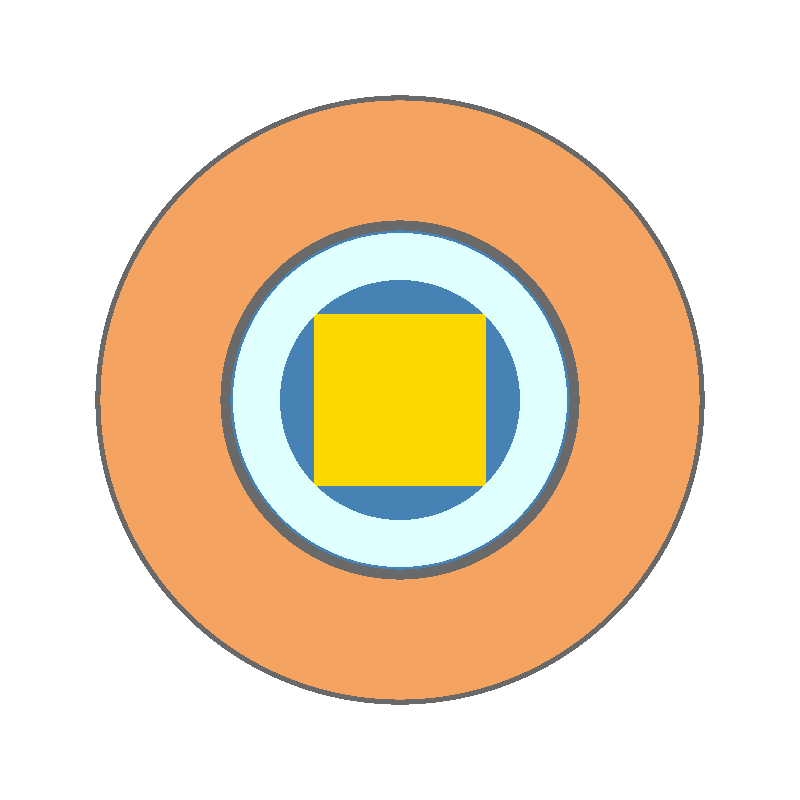

In [4]:
# Render the geometry plot inline
materials = openmc.Materials([
    spent_fuel, zircaloy, helium, ss304, carbon_steel, concrete, hom_fuel
])
materials.export_to_xml()
geometry.export_to_xml()

openmc.plot_geometry()

from IPython.display import Image
Image('plot_1.png')

## Cell 5 — Source Definition

Spent fuel emits:
1. **Spontaneous fission neutrons** — dominated by Cm-244 at 45 GWd/tHM, ~10yr cooling.
   We use a Watt fission spectrum characteristic of Cf-252 as a conservative approximation.
2. **Decay gamma photons** — dominated by Cs-137 (662 keV), Eu-154 (1.27 MeV), Co-60 (1.17/1.33 MeV).
   We define a discrete-line gamma source weighted by relative activity.

Both sources are uniformly distributed over the fuel basket volume (cylinder of radius r_basket).

> **Note**: For a production model, source spectra should be taken from an Origen/SCALE output
> for the specific fuel history. These simplified spectra are appropriate for demonstrating
> shielding methodology.

In [5]:
# ---------------------------------------------------------------------------
# Spatial distribution: uniform cylinder over fuel basket
# ---------------------------------------------------------------------------
spatial_dist = openmc.stats.CylindricalIndependent(
    r=openmc.stats.Uniform(0, r_basket),
    phi=openmc.stats.Uniform(0, 2*np.pi),
    z=openmc.stats.Uniform(-hz * 0.5, hz * 0.5),   # active fuel region only
    origin=(0.0, 0.0, 0.0)
)

# ---------------------------------------------------------------------------
# Source 1: Neutrons — Watt fission spectrum (Cf-252 parameters)
# a=0.977 MeV, b=2.996 MeV^-1  (conservative, representative of Cm-244 SF)
# ---------------------------------------------------------------------------
neutron_energy = openmc.stats.Watt(a=0.977e6, b=2.996e-6)  # eV units

neutron_source = openmc.IndependentSource(
    space=spatial_dist,
    angle=openmc.stats.Isotropic(),
    energy=neutron_energy,
    particle='neutron',
    strength=1.0    # relative; normalize to source rate in post-processing if needed
)

# ---------------------------------------------------------------------------
# Source 2: Photons — discrete gamma lines from major emitters
# Energies in eV, strengths proportional to relative photon emission rate
# Cs-137 (662 keV, ~85% yield) dominates at 10yr; Eu-154 and Co-60 also significant
# ---------------------------------------------------------------------------
gamma_energies = [
    0.662e6,   # Cs-137 / Ba-137m
    1.274e6,   # Eu-154 (1274 keV)
    0.123e6,   # Eu-154 (123 keV)
    1.173e6,   # Co-60
    1.333e6,   # Co-60
    0.898e6,   # Eu-154 (898 keV)
    0.722e6,   # Cs-134 (still present at 10yr)
    0.606e6,   # Cs-134
]
# Relative weights (approximate, based on specific activities at 10yr cooling)
gamma_weights = [
    1.000,  # Cs-137  — dominant
    0.120,  # Eu-154
    0.090,  # Eu-154
    0.050,  # Co-60
    0.050,  # Co-60
    0.040,  # Eu-154
    0.030,  # Cs-134
    0.025,  # Cs-134
]
# Normalize weights
gamma_weights = np.array(gamma_weights)
gamma_weights /= gamma_weights.sum()

gamma_energy_dist = openmc.stats.Discrete(gamma_energies, gamma_weights)

gamma_source = openmc.IndependentSource(
    space=spatial_dist,
    angle=openmc.stats.Isotropic(),
    energy=gamma_energy_dist,
    particle='photon',
    strength=10.0   # gammas are ~10x more important for dose at surface
)

print('Sources defined:')
print(f'  Neutron source: Watt spectrum, a=0.977 MeV, b=2.996 MeV^-1')
print(f'  Gamma source:   {len(gamma_energies)} discrete lines, '
      f'dominant at {gamma_energies[0]/1e6:.3f} MeV (Cs-137)')

Sources defined:
  Neutron source: Watt spectrum, a=0.977 MeV, b=2.996 MeV^-1
  Gamma source:   8 discrete lines, dominant at 0.662 MeV (Cs-137)


## Cell 6 — Tallies

We use three tallies:

1. **2D mesh flux tally** — neutron + photon flux on an XY mesh across the full cask cross-section.
   Used to produce dose-rate color maps.

2. **Radial flux tally** — flux as a function of radius using cylindrical mesh.
   Used for the 1D dose-rate vs. distance plot.

3. **Surface current tally** — particles crossing the outer steel surface,
   for a direct surface dose estimate.

Dose conversion factors come from ANSI/ANS-6.1.1-1977 (neutron) and ICRP-21 (photon),
implemented as energy function filters.

In [6]:
# ---------------------------------------------------------------------------
# Energy group structures for dose conversion
# ANSI/ANS-6.1.1 neutron flux-to-dose factors  (rem/hr per n/cm2/s)
# ---------------------------------------------------------------------------
# Neutron energies (MeV) and H*(10) dose coefficients (pSv·cm²)
neutron_dose_energies = np.array([
    1e-9, 1e-8, 2.53e-8, 1e-7, 2e-7, 5e-7, 1e-6, 2e-6, 5e-6,
    1e-5, 2e-5, 5e-5, 1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3,
    1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 3e-1, 5e-1, 7e-1,
    1.0,  1.5,  2.0,  3.0,  4.0,  5.0,  6.0,  7.0,
    8.0,  9.0,  1.0e1, 1.2e1, 1.4e1, 1.6e1, 1.8e1, 2.0e1
]) * 1e6  # convert MeV to eV

neutron_dose_coeff = np.array([
    3.76, 3.76, 3.76, 3.76, 3.76, 3.76, 3.76, 3.76, 3.76,
    3.76, 3.76, 3.76, 3.76, 3.76, 3.76, 3.76, 3.76, 3.76,
    4.80, 5.27, 7.72, 1.24e1, 2.40e1, 2.97e1, 3.54e1, 3.61e1,
    3.72e1, 3.72e1, 3.57e1, 3.16e1, 2.90e1, 2.72e1, 2.60e1, 2.51e1,
    2.45e1, 2.42e1, 2.39e1, 2.38e1, 2.39e1, 2.41e1, 2.44e1, 2.49e1
])  # pSv·cm²

# Photon energies (MeV) and H*(10) dose coefficients (pSv·cm²) — ICRP-116
photon_dose_energies = np.array([
    0.01, 0.015, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.10,
    0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.80, 1.00, 1.50, 2.00,
    3.00, 4.00, 5.00, 6.00, 8.00, 10.0
]) * 1e6  # eV

photon_dose_coeff = np.array([
    0.0288, 0.0560, 0.0812, 0.152, 0.202, 0.240, 0.269, 0.295, 0.323, 0.380,
    0.534, 0.692, 1.00, 1.32, 1.63, 1.91, 2.44, 2.94, 3.97, 4.93,
    6.76, 8.50, 10.1, 11.7, 14.9, 17.7
])  # pSv·cm²

# ---------------------------------------------------------------------------
# Tally 1: 2D XY mesh flux tally (for dose map)
# dimension must match the number of components in lower_left/upper_right (3D)
# ---------------------------------------------------------------------------
mesh_xy = openmc.RegularMesh(name='xy_mesh')
mesh_xy.dimension   = [200, 200, 1]
mesh_xy.lower_left  = (-r_scoring, -r_scoring, -1.0)
mesh_xy.upper_right = ( r_scoring,  r_scoring,  1.0)

mesh_filter_xy = openmc.MeshFilter(mesh_xy)

# Energy filters spanning the dose coefficient tables
n_energy_bins = np.concatenate([[1e-5], neutron_dose_energies[neutron_dose_energies < 2.01e7]])
p_energy_bins = np.concatenate([[1e3], photon_dose_energies])

n_energy_filter = openmc.EnergyFilter(n_energy_bins)
p_energy_filter = openmc.EnergyFilter(p_energy_bins)

n_particle_filter = openmc.ParticleFilter('neutron')
p_particle_filter = openmc.ParticleFilter('photon')

tally_n_mesh = openmc.Tally(name='neutron_flux_mesh')
tally_n_mesh.filters = [mesh_filter_xy, n_energy_filter, n_particle_filter]
tally_n_mesh.scores = ['flux']

tally_p_mesh = openmc.Tally(name='photon_flux_mesh')
tally_p_mesh.filters = [mesh_filter_xy, p_energy_filter, p_particle_filter]
tally_p_mesh.scores = ['flux']

# ---------------------------------------------------------------------------
# Tally 2: Cylindrical radial mesh (for 1D dose vs. radius plot)
# ---------------------------------------------------------------------------
mesh_cyl = openmc.CylindricalMesh(
    r_grid=np.linspace(0, r_scoring, 201),
    z_grid=np.array([-1.0, 1.0]),
    phi_grid=np.array([0, 2*np.pi]),
    name='cyl_mesh'
)

mesh_filter_cyl = openmc.MeshFilter(mesh_cyl)

tally_n_radial = openmc.Tally(name='neutron_flux_radial')
tally_n_radial.filters = [mesh_filter_cyl, n_particle_filter]
tally_n_radial.scores = ['flux']

tally_p_radial = openmc.Tally(name='photon_flux_radial')
tally_p_radial.filters = [mesh_filter_cyl, p_particle_filter]
tally_p_radial.scores = ['flux']

# ---------------------------------------------------------------------------
# Tally 3: Surface current on outer steel surface
# ---------------------------------------------------------------------------
surf_filter = openmc.SurfaceFilter(s_outer_steel)

tally_surf_n = openmc.Tally(name='surface_current_neutron')
tally_surf_n.filters = [surf_filter, n_particle_filter]
tally_surf_n.scores = ['current']

tally_surf_p = openmc.Tally(name='surface_current_photon')
tally_surf_p.filters = [surf_filter, p_particle_filter]
tally_surf_p.scores = ['current']

tallies = openmc.Tallies([
    tally_n_mesh, tally_p_mesh,
    tally_n_radial, tally_p_radial,
    tally_surf_n, tally_surf_p
])
tallies.export_to_xml()

print('Tallies defined:')
for t in tallies:
    print(f'  {t.name}')

Tallies defined:
  neutron_flux_mesh
  photon_flux_mesh
  neutron_flux_radial
  photon_flux_radial
  surface_current_neutron
  surface_current_photon


## Cell 7 — Settings and Run

In [7]:
settings = openmc.Settings()
settings.run_mode = 'fixed source'
settings.source   = [neutron_source, gamma_source]

settings.particles = 50_000       # increase to 500k+ for production
settings.batches   = 20
settings.photon_transport = True

settings.output = {'tallies': False, 'summary': True}

print(f'Settings configured.')
print(f'  Particles per batch: {settings.particles:,}')
print(f'  Batches:             {settings.batches}')
print(f'  Total particles:     {settings.particles * settings.batches:,}')
print(f'  Photon transport:    {settings.photon_transport}')

Settings configured.
  Particles per batch: 50,000
  Batches:             20
  Total particles:     1,000,000
  Photon transport:    True


In [8]:
import os
import glob

project_dir = '/home/eric/Documents/openMC_models/Dry_Cask'
os.chdir(project_dir)

# Remove any stale XML from previous runs so old files can't be picked up
for stale in glob.glob(os.path.join(project_dir, '*.xml')):
    os.remove(stale)
    print(f'Removed stale: {os.path.basename(stale)}')

# Export everything fresh
materials.export_to_xml()
geometry.export_to_xml()
tallies.export_to_xml()
settings.export_to_xml()

written = glob.glob(os.path.join(project_dir, '*.xml'))
print(f'\nExported {len(written)} XML files to {project_dir}:')
for f in sorted(written):
    print(f'  {os.path.basename(f)}')

print('\nRunning OpenMC fixed-source simulation...')
openmc.run(threads=7)
print('Simulation complete.')

Removed stale: tallies.xml
Removed stale: plots.xml
Removed stale: geometry.xml
Removed stale: materials.xml

Exported 4 XML files to /home/eric/Documents/openMC_models/Dry_Cask:
  geometry.xml
  materials.xml
  settings.xml
  tallies.xml

Running OpenMC fixed-source simulation...
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
          

## Cell 8 — Results: Dose Rate Maps and Radial Profile

We convert flux tallies to dose rates using the ANSI/ANS-6.1.1 flux-to-dose factors.
The conversion is:

$$\dot{H}^*(10) = \sum_g \phi_g \cdot h_g$$

where $\phi_g$ is the flux in energy group $g$ (n/cm²/s per source particle) and
$h_g$ is the dose coefficient in pSv·cm². Results are in arbitrary units proportional
to actual dose rate — normalize against a known source strength to get absolute mSv/hr.

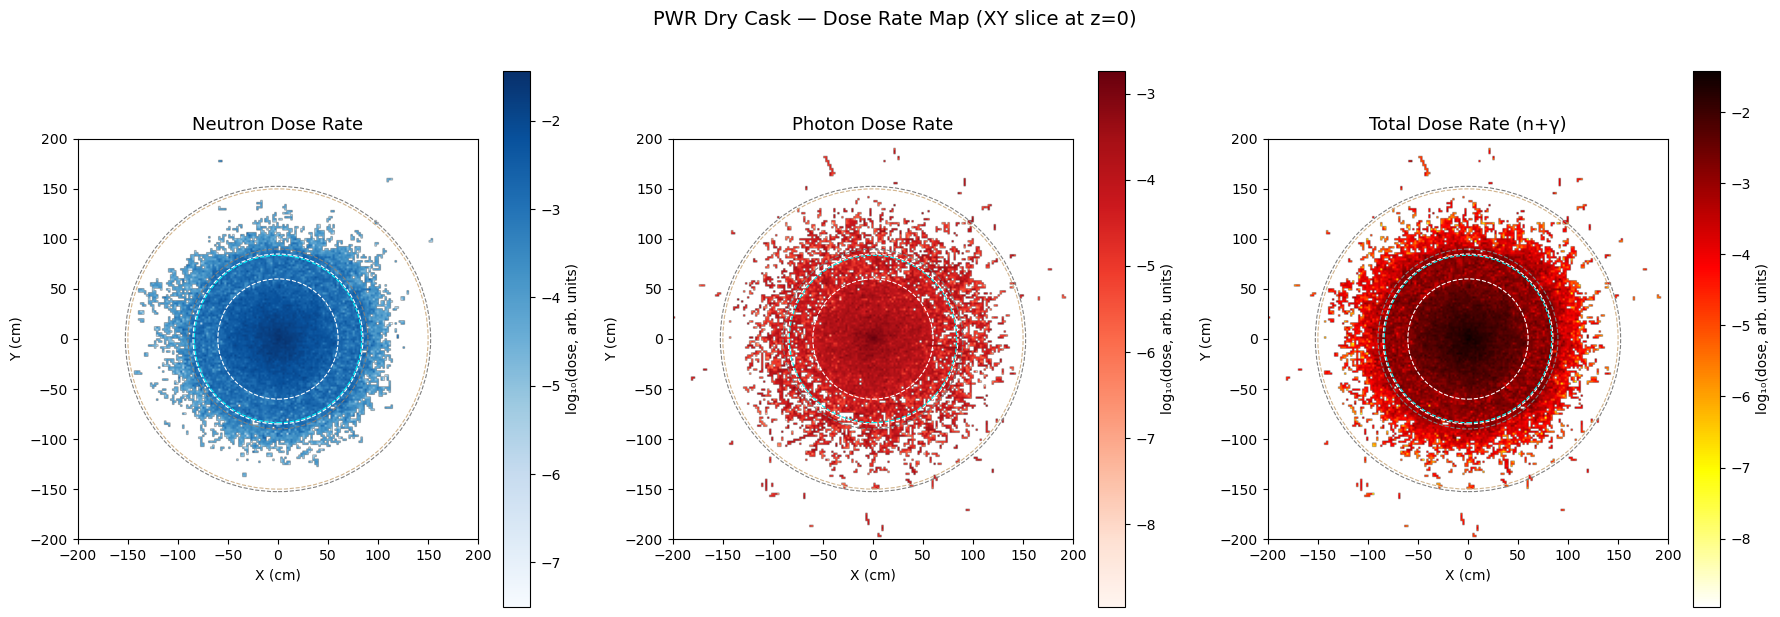

Saved dose_map_xy.png


In [9]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load statepoint
sp = openmc.StatePoint('statepoint.20.h5')

# ---------------------------------------------------------------------------
# Helper: compute dose from flux tally using flux-to-dose coefficients
# ---------------------------------------------------------------------------
def flux_to_dose(flux_data, dose_energies, dose_coeffs, energy_filter):
    """
    flux_data shape: (..., n_groups)
    energy_filter.bins shape: (n_groups, 2) — each row is [E_low, E_high] in eV
    Returns dose summed over energy groups.
    """
    bin_mids = energy_filter.bins[:, 0]   # use lower edge as representative energy
    h = np.interp(bin_mids, dose_energies, dose_coeffs, left=0, right=0)
    return np.sum(flux_data * h, axis=-1)

# ---------------------------------------------------------------------------
# 2D dose map from XY mesh tallies
# get_reshaped_data() returns (n_mesh_cells, n_groups, n_scores, 1, 1)
# n_mesh_cells = nx * ny * nz = 200 * 200 * 1 = 40000
# ---------------------------------------------------------------------------
t_n_mesh = sp.get_tally(name='neutron_flux_mesh')
t_p_mesh = sp.get_tally(name='photon_flux_mesh')

n_ef = t_n_mesh.find_filter(openmc.EnergyFilter)
p_ef = t_p_mesh.find_filter(openmc.EnergyFilter)

n_groups = n_ef.num_bins
p_groups = p_ef.num_bins

# shape: (40000, n_groups, 1, 1, 1) -> squeeze to (200, 200, n_groups)
n_flux_raw = t_n_mesh.get_reshaped_data()[:, :, 0, 0, 0].reshape(200, 200, n_groups)
p_flux_raw = t_p_mesh.get_reshaped_data()[:, :, 0, 0, 0].reshape(200, 200, p_groups)

# Convert to dose
n_dose_map    = flux_to_dose(n_flux_raw, neutron_dose_energies, neutron_dose_coeff, n_ef)
p_dose_map    = flux_to_dose(p_flux_raw, photon_dose_energies,  photon_dose_coeff,  p_ef)
total_dose_map = n_dose_map + p_dose_map

# ---------------------------------------------------------------------------
# Plot: 2D total dose rate map
# ---------------------------------------------------------------------------
extent = [-r_scoring, r_scoring, -r_scoring, r_scoring]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

dose_maps = [
    (n_dose_map,     'Neutron Dose Rate',    'Blues'),
    (p_dose_map,     'Photon Dose Rate',     'Reds'),
    (total_dose_map, 'Total Dose Rate (n+γ)','hot_r'),
]

for ax, (data, title, cmap) in zip(axes, dose_maps):
    safe_data = np.where(data > 0, data, np.nan)
    im = ax.imshow(
        np.log10(safe_data.T),
        origin='lower', extent=extent,
        cmap=cmap, aspect='equal'
    )
    plt.colorbar(im, ax=ax, label='log₁₀(dose, arb. units)')

    for r, color in [
        (r_basket,      'white'),
        (r_he_gap,      'cyan'),
        (r_mpc_wall,    'white'),
        (r_inner_steel, 'gray'),
        (r_concrete,    'tan'),
        (r_outer_steel, 'gray'),
    ]:
        circle = plt.Circle((0, 0), r, fill=False, color=color, linewidth=0.8, linestyle='--')
        ax.add_patch(circle)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('X (cm)')
    ax.set_ylabel('Y (cm)')

plt.suptitle('PWR Dry Cask — Dose Rate Map (XY slice at z=0)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('dose_map_xy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved dose_map_xy.png')

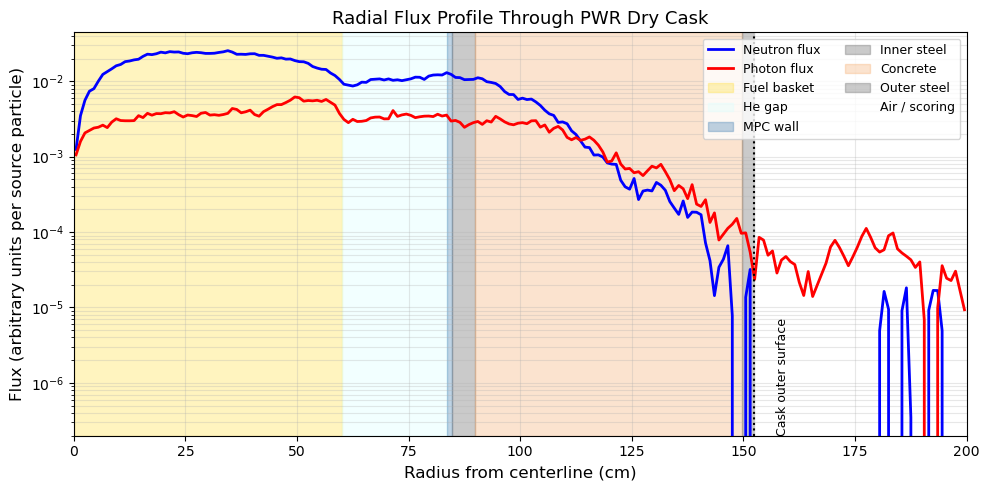

Saved radial_flux_profile.png


In [10]:
# ---------------------------------------------------------------------------
# Radial dose rate profile
# ---------------------------------------------------------------------------
t_n_rad = sp.get_tally(name='neutron_flux_radial')
t_p_rad = sp.get_tally(name='photon_flux_radial')

# Cylindrical mesh: shape (nr, nphi, nz) = (200, 1, 1)
n_rad_flux = t_n_rad.get_values(scores=['flux']).reshape(200)
p_rad_flux = t_p_rad.get_values(scores=['flux']).reshape(200)

# No energy-dependent dose for radial tally — use total flux as proxy
# (energy-integrated, so dose conversion would need a separate energy filter)
r_centers = 0.5 * (mesh_cyl.r_grid[:-1] + mesh_cyl.r_grid[1:])

fig, ax = plt.subplots(figsize=(10, 5))

mask = (n_rad_flux > 0) | (p_rad_flux > 0)
ax.semilogy(r_centers[mask], n_rad_flux[mask], 'b-',  lw=2, label='Neutron flux')
ax.semilogy(r_centers[mask], p_rad_flux[mask], 'r-',  lw=2, label='Photon flux')

# Shade material regions
region_bounds = [
    (0,             r_basket,      'gold',       'Fuel basket',    0.25),
    (r_basket,      r_he_gap,      'lightcyan',  'He gap',         0.40),
    (r_he_gap,      r_mpc_wall,    'steelblue',  'MPC wall',       0.35),
    (r_mpc_wall,    r_inner_steel, 'dimgray',    'Inner steel',    0.35),
    (r_inner_steel, r_concrete,    'sandybrown', 'Concrete',       0.30),
    (r_concrete,    r_outer_steel, 'dimgray',    'Outer steel',    0.35),
    (r_outer_steel, r_scoring,     'white',      'Air / scoring',  0.15),
]
for r_lo, r_hi, color, label, alpha in region_bounds:
    ax.axvspan(r_lo, r_hi, alpha=alpha, color=color, label=label)

ax.set_xlabel('Radius from centerline (cm)', fontsize=12)
ax.set_ylabel('Flux (arbitrary units per source particle)', fontsize=12)
ax.set_title('Radial Flux Profile Through PWR Dry Cask', fontsize=13)
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.set_xlim(0, r_scoring)
ax.grid(True, which='both', alpha=0.3)

# Annotate the outer surface
ax.axvline(r_outer_steel, color='k', linestyle=':', lw=1.5, label='Outer surface')
ax.annotate('Cask outer surface', xy=(r_outer_steel, ax.get_ylim()[0]),
            xytext=(r_outer_steel+5, ax.get_ylim()[0]),
            fontsize=9, rotation=90, va='bottom')

plt.tight_layout()
plt.savefig('radial_flux_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved radial_flux_profile.png')

In [11]:
# ---------------------------------------------------------------------------
# Back-calculation: maximum permissible source strength
#
# The surface current tally scores particles/cm²/s per source particle/s.
# To get dose rate:
#   H_dot [mSv/hr] = J [particles/cm²/s per src/s] * S [src/s]
#                    * h [pSv·cm²] * (1e-12 Sv/pSv) * (1e3 mSv/Sv) * 3600 s/hr
#                  = J * S * h * 3.6e-9
#
# We use a conservative single-energy flux-to-dose factor at the dominant energy
# for each particle type:
#   Neutrons: fast spectrum average ~20 pSv·cm²  (from ANSI/ANS-6.1.1, ~1 MeV range)
#   Photons:  662 keV (Cs-137 dominant) -> h = 1.91 pSv·cm² (ICRP-116)
#
# Regulatory limits:
#   10 CFR 72.104 / 10 CFR 71.47: 2 mSv/hr (200 mrem/hr) at cask surface (controlled)
#   ALARA / unrestricted area:     0.02 mSv/hr (2 mrem/hr) at 1 m from surface
# ---------------------------------------------------------------------------

import numpy as np

# --- Tally results (from simulation output) ---
J_n   = 3.6300e-04   # neutron surface current per source particle [particles/cm²/s per src/s]
J_p   = 6.6330e-03   # photon surface current per source particle
J_n_unc = 5.5919e-05
J_p_unc = 2.8741e-04

# --- Flux-to-dose conversion factors ---
# Neutron: use ~20 pSv·cm² (conservative fast-neutron average from ANSI/ANS-6.1.1)
h_n = 20.0   # pSv·cm²

# Photon: Cs-137 dominates at 662 keV -> interpolate ICRP-116
#   At 0.60 MeV: 1.91 pSv·cm²,  at 0.80 MeV: 2.44 pSv·cm²
#   Linear interp at 0.662 MeV:
h_p = 1.91 + (2.44 - 1.91) * (0.662 - 0.60) / (0.80 - 0.60)
print(f'Photon dose coeff at 662 keV (Cs-137): {h_p:.3f} pSv·cm²')

# Conversion factor: pSv·cm² -> mSv/hr
# pSv * 1e-12 Sv/pSv * 1e3 mSv/Sv * 3600 s/hr = 3.6e-9 mSv·s/hr per pSv
conv = 3.6e-9   # mSv·hr / (pSv·cm²) per (particle/cm²/s)

# --- Dose rate per unit source strength ---
# H_dot [mSv/hr] = J [/cm²/s per src/s] * h [pSv·cm²] * conv * S [src/s]
dose_per_src_n = J_n * h_n * conv   # mSv/hr per source particle/s
dose_per_src_p = J_p * h_p * conv
dose_per_src_total = dose_per_src_n + dose_per_src_p

print(f'\nDose rate at cask surface per unit source strength:')
print(f'  Neutron:  {dose_per_src_n:.4e} mSv/hr per n/s')
print(f'  Photon:   {dose_per_src_p:.4e} mSv/hr per γ/s')
print(f'  Total:    {dose_per_src_total:.4e} mSv/hr per src/s')

# --- Back-calculate maximum permissible source strength ---
limit_controlled   = 2.00    # mSv/hr  — 10 CFR 72.104 at cask surface (controlled area)
limit_uncontrolled = 0.02    # mSv/hr  — 10 CFR 20.1301 at boundary (unrestricted)

# Note: the neutron and photon sources were defined with relative strengths 1.0 and 10.0.
# The simulation treats them as independent sources. The surface currents above
# already reflect those relative weights. To get a meaningful total we need to
# account for the fact that the photon source was weighted 10x stronger in the sim.
# Adjust photon current back to "per real photon source particle":
photon_weight_in_sim = 10.0
J_p_normalized = J_p / photon_weight_in_sim
dose_per_src_p_norm = J_p_normalized * h_p * conv

# For a real cask, neutrons and photons come from the same source (spent fuel),
# so the ratio of photons to neutrons is fixed by the physics (~10:1 is reasonable).
# We define S as the total source rate (n+γ combined), with the ratio fixed at 1:10.
# Total dose = S_n * dose_per_src_n + S_γ * dose_per_src_p_norm
#            = S_n * (dose_per_src_n + 10 * dose_per_src_p_norm)
dose_per_neutron_src = dose_per_src_n + 10.0 * dose_per_src_p_norm

S_max_controlled   = limit_controlled   / dose_per_neutron_src
S_max_uncontrolled = limit_uncontrolled / dose_per_neutron_src

print(f'\n--- Back-calculated maximum neutron source rate (S_n) ---')
print(f'  Regulatory limit (controlled,   10 CFR 72.104): {limit_controlled:.2f} mSv/hr')
print(f'  Max S_n:  {S_max_controlled:.3e} n/s')
print(f'  Corresponding γ source: {10*S_max_controlled:.3e} γ/s')

print(f'\n  Regulatory limit (uncontrolled, 10 CFR 20.1301): {limit_uncontrolled:.4f} mSv/hr')
print(f'  Max S_n:  {S_max_uncontrolled:.3e} n/s')
print(f'  Corresponding γ source: {10*S_max_uncontrolled:.3e} γ/s')

# --- Propagate uncertainty ---
# Fractional uncertainty from tally statistics
frac_unc_n = J_n_unc / J_n
frac_unc_p = J_p_unc / J_p
# Combined fractional uncertainty (quadrature, neutron contribution small vs photon)
frac_unc_total = np.sqrt((dose_per_src_n * frac_unc_n)**2 +
                          (dose_per_src_p_norm * 10 * frac_unc_p)**2) / dose_per_neutron_src
print(f'\n  Statistical uncertainty on S_max: ±{frac_unc_total*100:.1f}%')
print(f'  (Dominated by {"photon" if frac_unc_p < frac_unc_n else "neutron"} tally uncertainty)')
print(f'\nNOTE: This result is per source particle — normalize S_n against a known')
print(f'  spent fuel neutron emission rate (e.g. from ORIGEN/SCALE) for absolute limits.')

Photon dose coeff at 662 keV (Cs-137): 2.074 pSv·cm²

Dose rate at cask surface per unit source strength:
  Neutron:  2.6136e-11 mSv/hr per n/s
  Photon:   4.9532e-11 mSv/hr per γ/s
  Total:    7.5668e-11 mSv/hr per src/s

--- Back-calculated maximum neutron source rate (S_n) ---
  Regulatory limit (controlled,   10 CFR 72.104): 2.00 mSv/hr
  Max S_n:  2.643e+10 n/s
  Corresponding γ source: 2.643e+11 γ/s

  Regulatory limit (uncontrolled, 10 CFR 20.1301): 0.0200 mSv/hr
  Max S_n:  2.643e+08 n/s
  Corresponding γ source: 2.643e+09 γ/s

  Statistical uncertainty on S_max: ±6.0%
  (Dominated by photon tally uncertainty)

NOTE: This result is per source particle — normalize S_n against a known
  spent fuel neutron emission rate (e.g. from ORIGEN/SCALE) for absolute limits.
